# Task 2: Visual Analysis for Client Requests

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)

In [2]:
# Load dataset
dim_stores = pd.read_csv('datasets/dim_stores.csv')
dim_products = pd.read_csv('datasets/dim_products.csv')
dim_campaigns = pd.read_csv('datasets/dim_campaigns.csv')
events = pd.read_csv('datasets/fact_events.csv')

print('dim_stores:', dim_stores.shape)
print('dim_products:', dim_products.shape)
print('dim_campaigns:', dim_campaigns.shape)
print('events:', events.shape)

dim_stores: (50, 2)
dim_products: (15, 3)
dim_campaigns: (2, 4)
events: (1500, 9)


In [3]:
# Combine required dimensions once for downstream analysis
df = (
    events
    .merge(dim_stores, on='store_id', how='left')
    .merge(dim_products, on='product_code', how='left')
    .merge(dim_campaigns[['campaign_id', 'campaign_name']], on='campaign_id', how='left')
).copy()

df['revenue_before'] = df['base_price(before_promo)'] * df['quantity_sold(before_promo)']
df['revenue_after'] = df['base_price(after_promo)'] * df['quantity_sold(after_promo)']

df.head()

,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo),city,product_name,category,campaign_name,revenue_before,revenue_after
0,8481be,STCHE-1,CAMP_DIW_01,P04,290,327.0,25% OFF,217,287,Chennai,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Diwali,94830.0,62279
1,20618e,STCHE-3,CAMP_SAN_01,P04,370,379.0,BOGOF,185,1622,Chennai,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Sankranti,140230.0,300070
2,f30579,STBLR-9,CAMP_DIW_01,P02,860,337.0,33% OFF,576,488,Bengaluru,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples,Diwali,289820.0,281088
3,4f570c,STBLR-7,CAMP_DIW_01,P05,55,122.0,25% OFF,41,107,Bengaluru,Atliq_Scrub_Sponge_For_Dishwash,Home Care,Diwali,6710.0,4387
4,6d153f,STHYD-5,CAMP_SAN_01,P15,3000,122.0,500 Cashback,2500,272,Hyderabad,Atliq_Home_Essential_8_Product_Combo,Combo1,Sankranti,366000.0,680000


## 1) Number of stores in each city + Bengaluru vs Hyderabad/Chennai

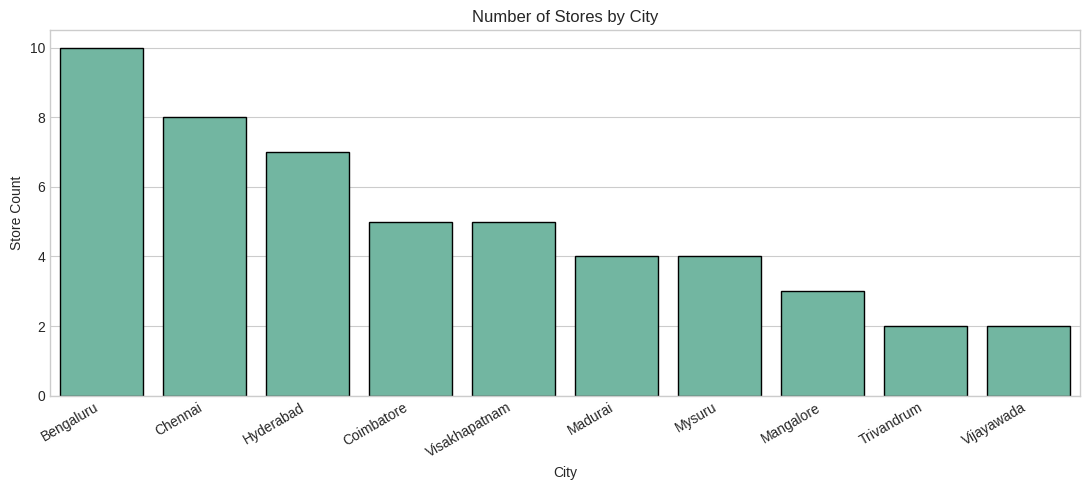

City with highest stores: Bengaluru - 10
Bengaluru vs Hyderabad vs Chennai:
city
Bengaluru    10
Chennai       8
Hyderabad     7
Name: store_count, dtype: int64


In [4]:
store_count = dim_stores.groupby('city', as_index=False)['store_id'].nunique()
store_count = store_count.rename(columns={'store_id': 'store_count'})
store_count = store_count.sort_values('store_count', ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(data=store_count, x='city', y='store_count', edgecolor='black')
plt.title('Number of Stores by City')
plt.xlabel('City')
plt.ylabel('Store Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

top_city = store_count.iloc[0]
comparison = store_count.loc[store_count['city'].isin(['Bengaluru', 'Hyderabad', 'Chennai'])].set_index('city')['store_count']

print('City with highest stores:', top_city['city'], '-', int(top_city['store_count']))
print('Bengaluru vs Hyderabad vs Chennai:')
print(comparison.sort_values(ascending=False))

## 2) Sankranti quantity sold after promo by category (percentage contribution)

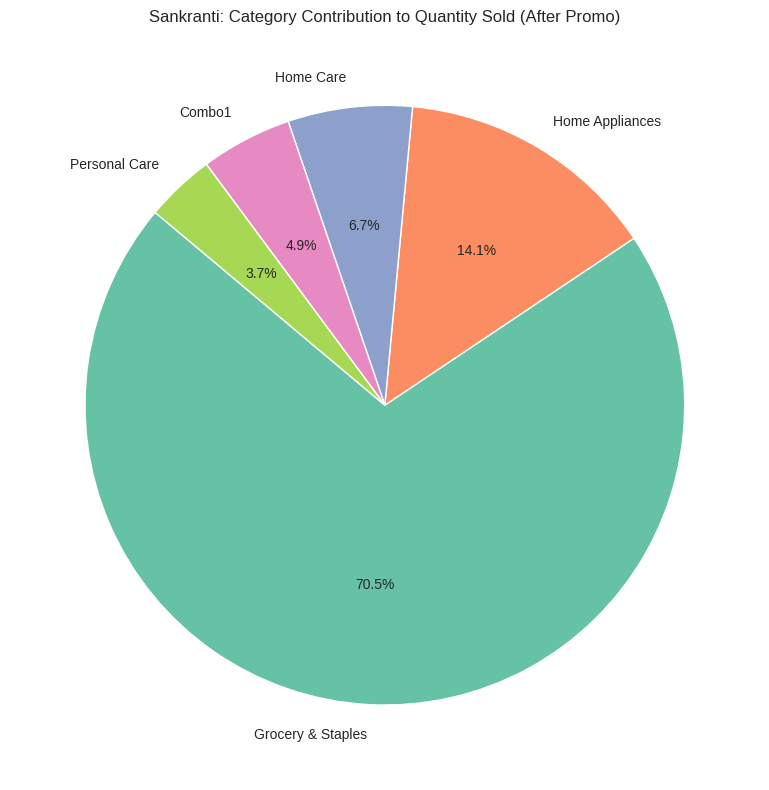

,category,quantity_sold(after_promo),contribution_%
1,Grocery & Staples,177724,70.51
2,Home Appliances,35610,14.13
3,Home Care,16894,6.70
0,Combo1,12411,4.92
4,Personal Care,9430,3.74


In [5]:
sankranti_category_qty = (
    df.loc[df['campaign_name'] == 'Sankranti']
    .groupby('category', as_index=False)['quantity_sold(after_promo)']
    .sum()
    .sort_values('quantity_sold(after_promo)', ascending=False)
)

total_sankranti_qty = sankranti_category_qty['quantity_sold(after_promo)'].sum()
sankranti_category_qty['contribution_%'] = (
    sankranti_category_qty['quantity_sold(after_promo)'] / total_sankranti_qty * 100
)

plt.figure(figsize=(8, 8))
plt.pie(
    sankranti_category_qty['quantity_sold(after_promo)'],
    labels=sankranti_category_qty['category'],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Sankranti: Category Contribution to Quantity Sold (After Promo)')
plt.tight_layout()
plt.show()

sankranti_category_qty.round(2)

## 3) Correlation between base price (after promo) and quantity sold (after promo)

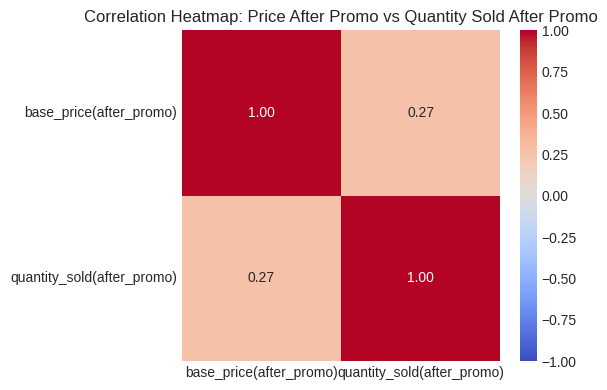

Correlation value: 0.269


In [6]:
corr_df = df[['base_price(after_promo)', 'quantity_sold(after_promo)']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap: Price After Promo vs Quantity Sold After Promo')
plt.tight_layout()
plt.show()

corr_value = corr_df.loc['base_price(after_promo)', 'quantity_sold(after_promo)']
print(f'Correlation value: {corr_value:.3f}')

## 4) Distribution of quantity sold before promo by product category

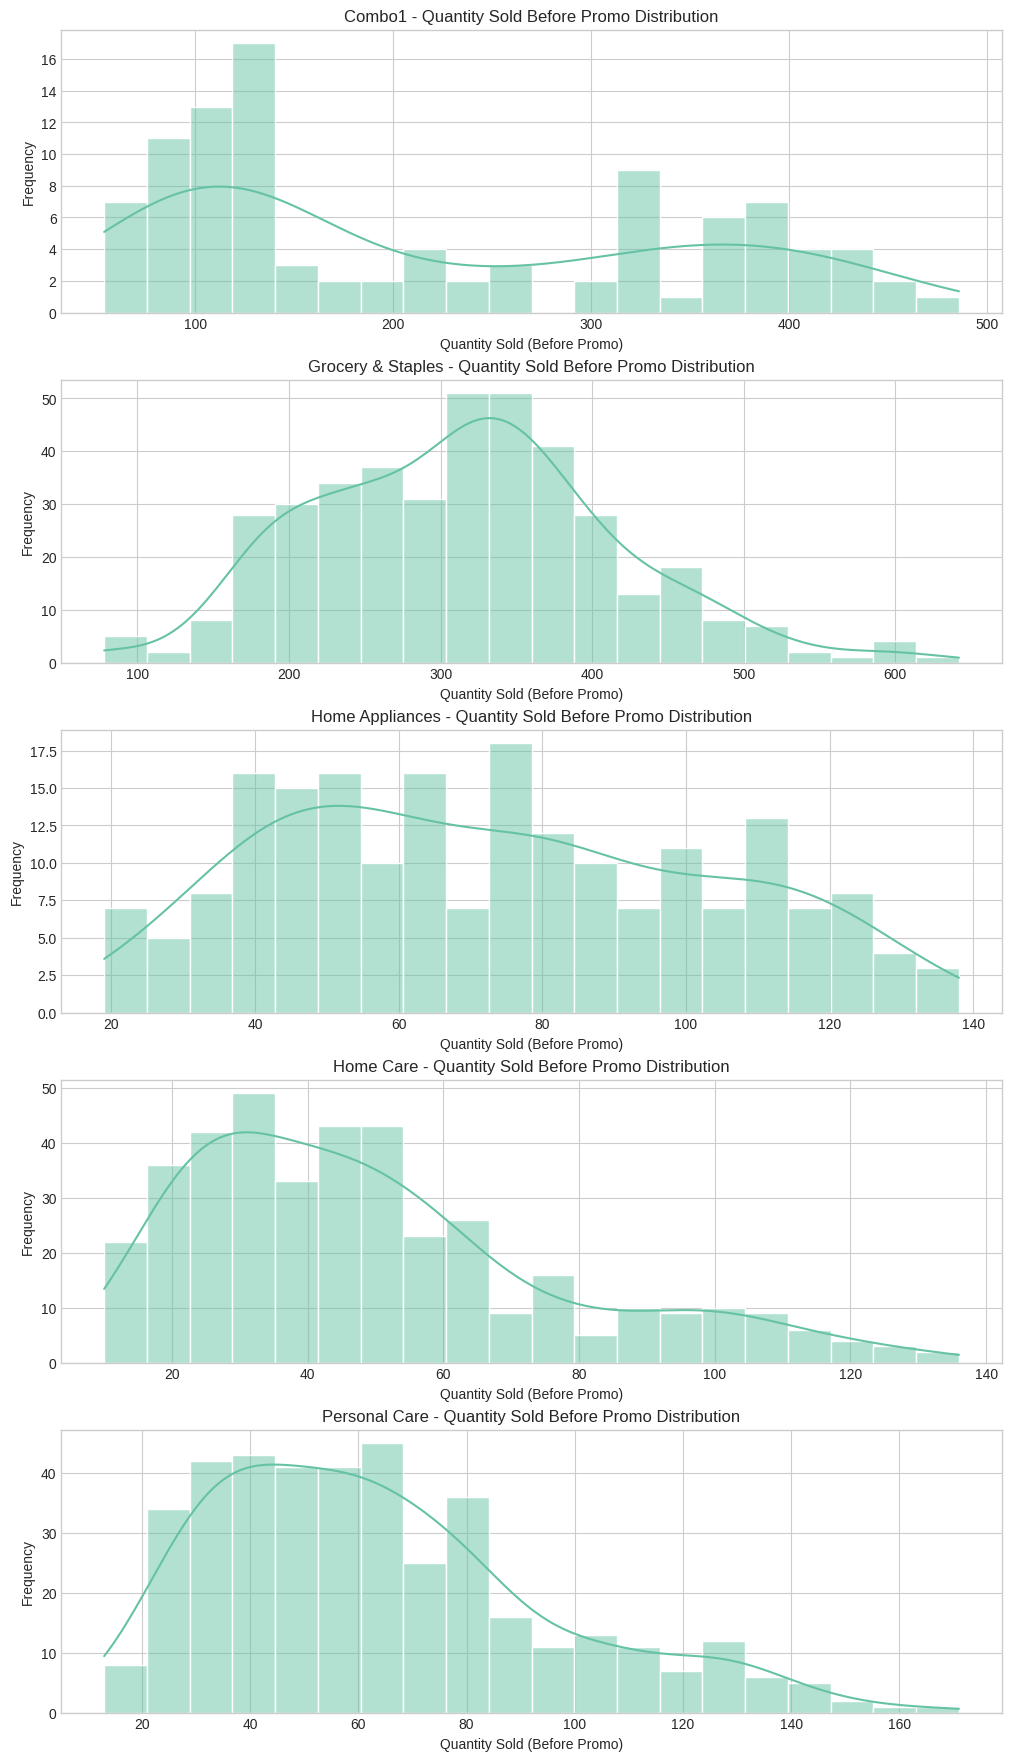

,index,category,mean,median,std,min,max
0,0,Combo1,217.300,147.0,129.561303,54.0,486.0
1,1,Grocery & Staples,314.790,317.0,99.001055,78.0,642.0
2,2,Home Appliances,73.280,72.0,30.021125,19.0,138.0
3,3,Home Care,49.585,43.0,27.331031,10.0,136.0
4,4,Personal Care,63.785,58.0,31.228863,13.0,171.0


In [7]:
categories = sorted(df['category'].dropna().unique())
n_categories = len(categories)

fig, axes = plt.subplots(n_categories, 1, figsize=(10, 3.5 * n_categories), constrained_layout=True)
if n_categories == 1:
    axes = [axes]

for ax, category in zip(axes, categories):
    values = df.loc[df['category'] == category, 'quantity_sold(before_promo)']
    sns.histplot(values, bins=20, kde=True, ax=ax)
    ax.set_title(f'{category} - Quantity Sold Before Promo Distribution')
    ax.set_xlabel('Quantity Sold (Before Promo)')
    ax.set_ylabel('Frequency')

plt.show()

category_distribution_summary = (
    df.groupby('category', as_index=False)['quantity_sold(before_promo)']
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .reset_index()
)
category_distribution_summary

## 5) ISU% across cities (highest and smallest change)

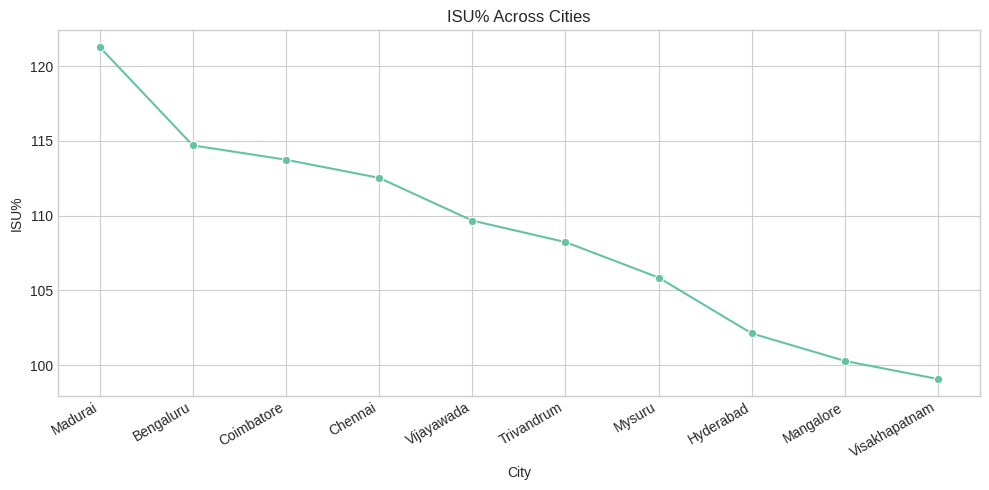

Highest ISU% city: {'city': 'Madurai', 'ISU%': 121.27644469686214}
Smallest change city: {'city': 'Visakhapatnam', 'ISU%': 99.07260667957974}


,city,ISU%
4,Madurai,121.28
0,Bengaluru,114.70
2,Coimbatore,113.74
1,Chennai,112.52
8,Vijayawada,109.67
7,Trivandrum,108.23
6,Mysuru,105.86
3,Hyderabad,102.12
5,Mangalore,100.28
9,Visakhapatnam,99.07


In [8]:
city_isu = (
    df.groupby('city', as_index=False)[['quantity_sold(before_promo)', 'quantity_sold(after_promo)']]
    .sum()
)

city_isu['ISU%'] = np.where(
    city_isu['quantity_sold(before_promo)'] == 0,
    np.nan,
    (city_isu['quantity_sold(after_promo)'] - city_isu['quantity_sold(before_promo)'])
    / city_isu['quantity_sold(before_promo)'] * 100
)
city_isu = city_isu.sort_values('ISU%', ascending=False)

plt.figure(figsize=(10, 5))
sns.lineplot(data=city_isu, x='city', y='ISU%', marker='o')
plt.title('ISU% Across Cities')
plt.xlabel('City')
plt.ylabel('ISU%')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

highest_city = city_isu.iloc[0][['city', 'ISU%']]
lowest_city = city_isu.iloc[-1][['city', 'ISU%']]
print('Highest ISU% city:', highest_city.to_dict())
print('Smallest change city:', lowest_city.to_dict())
city_isu[['city', 'ISU%']].round(2)

## 6) Hyderabad: relationship between incremental revenue and incremental sold units by promo type

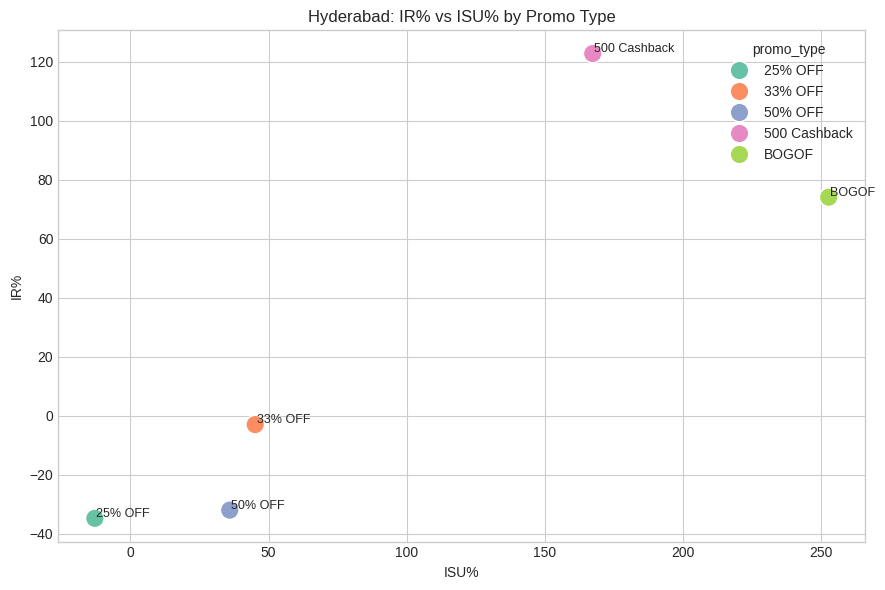

Hyderabad promo with highest ISU%: {'promo_type': 'BOGOF', 'ISU%': 252.829793911497}
Hyderabad promo with highest IR%: {'promo_type': '500 Cashback', 'IR%': 122.81882397861779}


,promo_type,ISU%,IR%
4,BOGOF,252.83,74.12
3,500 Cashback,167.38,122.82
1,33% OFF,45.17,-2.98
2,50% OFF,35.94,-31.99
0,25% OFF,-12.90,-34.77


In [9]:
hyderabad = df.loc[df['city'] == 'Hyderabad'].copy()

hyderabad_promo = (
    hyderabad.groupby('promo_type', as_index=False)[
        ['revenue_before', 'revenue_after', 'quantity_sold(before_promo)', 'quantity_sold(after_promo)']
    ]
    .sum()
)

hyderabad_promo['IR%'] = np.where(
    hyderabad_promo['revenue_before'] == 0,
    np.nan,
    (hyderabad_promo['revenue_after'] - hyderabad_promo['revenue_before']) / hyderabad_promo['revenue_before'] * 100
)
hyderabad_promo['ISU%'] = np.where(
    hyderabad_promo['quantity_sold(before_promo)'] == 0,
    np.nan,
    (hyderabad_promo['quantity_sold(after_promo)'] - hyderabad_promo['quantity_sold(before_promo)'])
    / hyderabad_promo['quantity_sold(before_promo)'] * 100
)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=hyderabad_promo, x='ISU%', y='IR%', hue='promo_type', s=180)
for _, row in hyderabad_promo.iterrows():
    plt.text(row['ISU%'] + 0.5, row['IR%'] + 0.5, row['promo_type'], fontsize=9)
plt.title('Hyderabad: IR% vs ISU% by Promo Type')
plt.xlabel('ISU%')
plt.ylabel('IR%')
plt.tight_layout()
plt.show()

top_isu_promo = hyderabad_promo.sort_values('ISU%', ascending=False).iloc[0][['promo_type', 'ISU%']]
top_ir_promo = hyderabad_promo.sort_values('IR%', ascending=False).iloc[0][['promo_type', 'IR%']]

print('Hyderabad promo with highest ISU%:', top_isu_promo.to_dict())
print('Hyderabad promo with highest IR%:', top_ir_promo.to_dict())
hyderabad_promo[['promo_type', 'ISU%', 'IR%']].round(2).sort_values('ISU%', ascending=False)

## 7) Bengaluru revenue before vs after promo across product categories

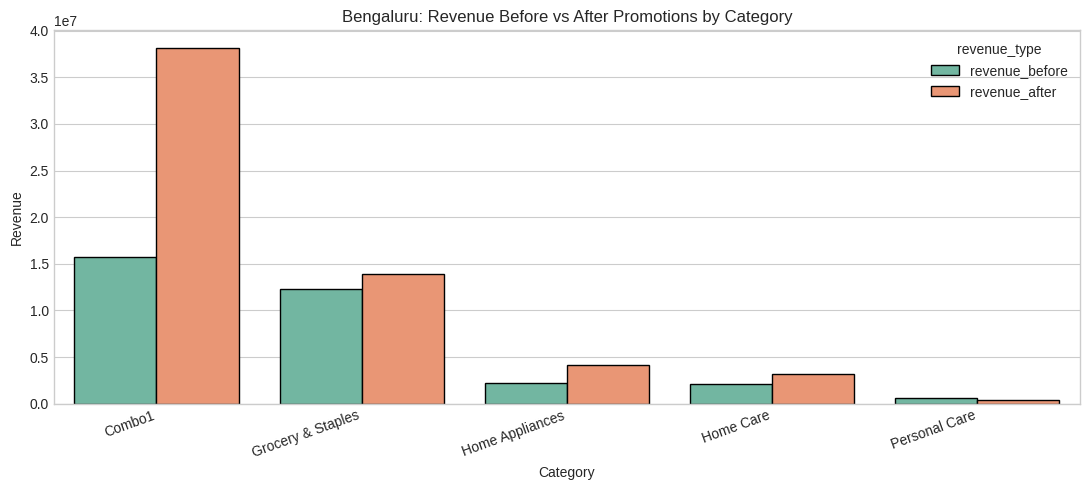

,category,revenue_before,revenue_after,absolute_change,IR%
0,Combo1,15777000.0,38125000,22348000.0,141.65
2,Home Appliances,2188810.0,4122680,1933870.0,88.35
3,Home Care,2104460.0,3180020,1075560.0,51.11
1,Grocery & Staples,12262460.0,13861259,1598799.0,13.04
4,Personal Care,576321.0,389629,-186692.0,-32.39


In [10]:
bengaluru = df.loc[df['city'] == 'Bengaluru'].copy()

blr_category_revenue = (
    bengaluru.groupby('category', as_index=False)[['revenue_before', 'revenue_after']]
    .sum()
)

blr_plot_df = blr_category_revenue.melt(
    id_vars='category',
    value_vars=['revenue_before', 'revenue_after'],
    var_name='revenue_type',
    value_name='revenue'
)

plt.figure(figsize=(11, 5))
sns.barplot(data=blr_plot_df, x='category', y='revenue', hue='revenue_type', edgecolor='black')
plt.title('Bengaluru: Revenue Before vs After Promotions by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

blr_category_revenue['absolute_change'] = blr_category_revenue['revenue_after'] - blr_category_revenue['revenue_before']
blr_category_revenue['IR%'] = np.where(
    blr_category_revenue['revenue_before'] == 0,
    np.nan,
    blr_category_revenue['absolute_change'] / blr_category_revenue['revenue_before'] * 100
)

blr_category_revenue.sort_values('IR%', ascending=False).round(2)

## Final Answers Snapshot

In [11]:
final_answers = {
    '1_city_with_most_stores': top_city.to_dict(),
    '1_bengaluru_hyderabad_chennai_store_counts': comparison.to_dict(),
    '2_sankranti_category_contribution_percent': sankranti_category_qty[['category', 'contribution_%']].round(2).to_dict('records'),
    '3_price_qty_after_promo_correlation': round(float(corr_value), 4),
    '5_city_isu_percent': city_isu[['city', 'ISU%']].round(2).to_dict('records'),
    '5_highest_isu_city': highest_city.to_dict(),
    '5_smallest_change_city': lowest_city.to_dict(),
    '6_hyderabad_top_isu_promo': top_isu_promo.to_dict(),
    '6_hyderabad_top_ir_promo': top_ir_promo.to_dict(),
    '7_bengaluru_category_revenue': blr_category_revenue.round(2).to_dict('records')
}

final_answers

{'1_city_with_most_stores': {'city': 'Bengaluru', 'store_count': 10},
 '1_bengaluru_hyderabad_chennai_store_counts': {'Bengaluru': 10,
  'Chennai': 8,
  'Hyderabad': 7},
 '2_sankranti_category_contribution_percent': [{'category': 'Grocery & Staples',
   'contribution_%': 70.51},
  {'category': 'Home Appliances', 'contribution_%': 14.13},
  {'category': 'Home Care', 'contribution_%': 6.7},
  {'category': 'Combo1', 'contribution_%': 4.92},
  {'category': 'Personal Care', 'contribution_%': 3.74}],
 '3_price_qty_after_promo_correlation': 0.2694,
 '5_city_isu_percent': [{'city': 'Madurai', 'ISU%': 121.28},
  {'city': 'Bengaluru', 'ISU%': 114.7},
  {'city': 'Coimbatore', 'ISU%': 113.74},
  {'city': 'Chennai', 'ISU%': 112.52},
  {'city': 'Vijayawada', 'ISU%': 109.67},
  {'city': 'Trivandrum', 'ISU%': 108.23},
  {'city': 'Mysuru', 'ISU%': 105.86},
  {'city': 'Hyderabad', 'ISU%': 102.12},
  {'city': 'Mangalore', 'ISU%': 100.28},
  {'city': 'Visakhapatnam', 'ISU%': 99.07}],
 '5_highest_isu_city'